In [2]:
import miepython
import numpy as np
import matplotlib.pyplot as plt

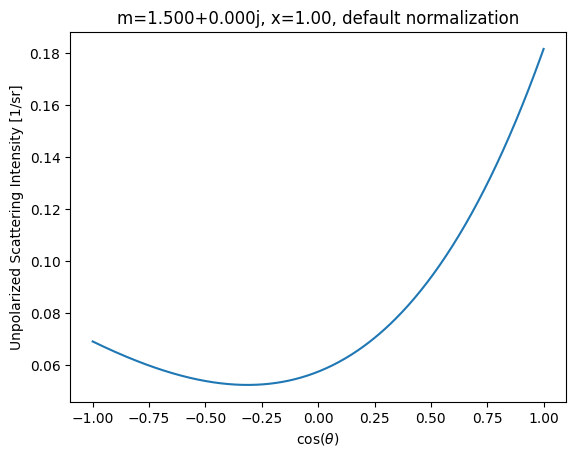

 Normalization    Total  Expected
        albedo    1.000     1.000
           one    1.000     1.000
           4pi   12.566    12.566
          qsca    0.215     0.215
          qext    0.215     0.215
        bohren    2.703     2.703
      wiscombe    0.676     0.676


In [3]:
m = 1.5
x = 1
mu = np.linspace(-1,1,501)
intensity = miepython.i_unpolarized(m,x,mu)
qext, qsca, qback, g = miepython.mie(m,x)

norms = ['albedo','one','4pi','qsca','qext','bohren','wiscombe']
expected = [qsca/qext,1.0,4*np.pi,qsca,qext,4*np.pi*x**2*qsca,np.pi*x**2*qsca]

plt.plot(mu,intensity)
plt.xlabel(r'$\cos(\theta)$')
plt.ylabel('Unpolarized Scattering Intensity [1/sr]')
plt.title('m=%.3f%+.3fj, x=%.2f, default normalization'%(m.real,m.imag,x))
plt.show()


print(' Normalization    Total  Expected')

for i,norm in enumerate(norms):

    intensity = miepython.i_unpolarized(m,x,mu,norm)
    total = 2 * np.pi * np.trapz(intensity, mu)
    print("%14s %8.3f  %8.3f" % (norm, total, expected[i]))

In [ ]:
m = 1.5 - 1.5j
x = 1
mu = np.linspace(-1,1,501)
intensity = miepython.i_unpolarized(m,x,mu)
qext, qsca, qback, g = miepython.mie(m,x)

norms = ['albedo','one','4pi','qsca','qext','bohren','wiscombe']
expected = [qsca/qext,1.0,4*np.pi,qsca,qext,4*np.pi*x**2*qsca,np.pi*x**2*qsca]

plt.plot(mu,intensity)
plt.xlabel(r'$\cos(\theta)$')
plt.ylabel('Unpolarized Scattering Intensity [1/sr]')
plt.title('m=%.3f%+.3fj, x=%.2f, default normalization'%(m.real,m.imag,x))
plt.show()

print(' Normalization    Total  Expected')

for i,norm in enumerate(norms):

    intensity = miepython.i_unpolarized(m,x,mu,norm)
    total = 2 * np.pi * np.trapz(intensity, mu)
    print("%14s %8.3f  %8.3f" % (norm, total, expected[i]))

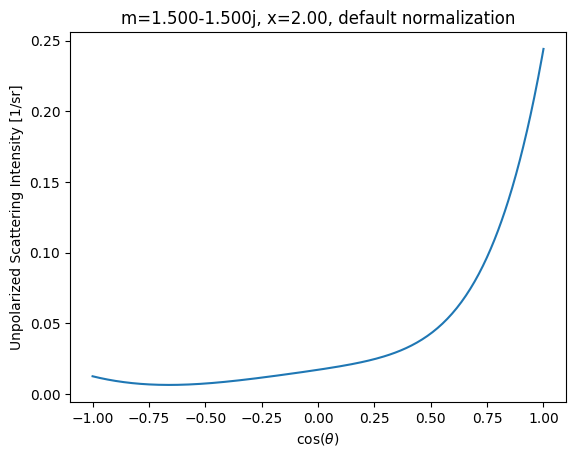

 Normalization    Total  Expected
        albedo    0.496     0.496
           one    1.000     1.000
           4pi   12.567    12.566
          qsca    1.523     1.523
          qext    3.069     3.068
        bohren   76.579    76.576
      wiscombe   19.145    19.144


In [4]:
m = 1.5-1.5j
x = 2
theta = np.linspace(np.pi,0,361)
mu = np.cos(theta)

intensity = miepython.i_unpolarized(m,x,mu)
qext, qsca, qback, g = miepython.mie(m,x)

norms = ['albedo','one','4pi','qsca','qext','bohren','wiscombe']
expected = [qsca/qext,1.0,4*np.pi,qsca,qext,4*np.pi*x**2*qsca,np.pi*x**2*qsca]

plt.plot(mu,intensity)
plt.xlabel(r'$\cos(\theta)$')
plt.ylabel('Unpolarized Scattering Intensity [1/sr]')
plt.title('m=%.3f%+.3fj, x=%.2f, default normalization'%(m.real,m.imag,x))
plt.show()

print(' Normalization    Total  Expected')

for i,norm in enumerate(norms):

    intensity = miepython.i_unpolarized(m,x,mu,norm)
    total = 2 * np.pi * np.trapz(intensity, mu)
    print("%14s %8.3f  %8.3f" % (norm, total, expected[i]))

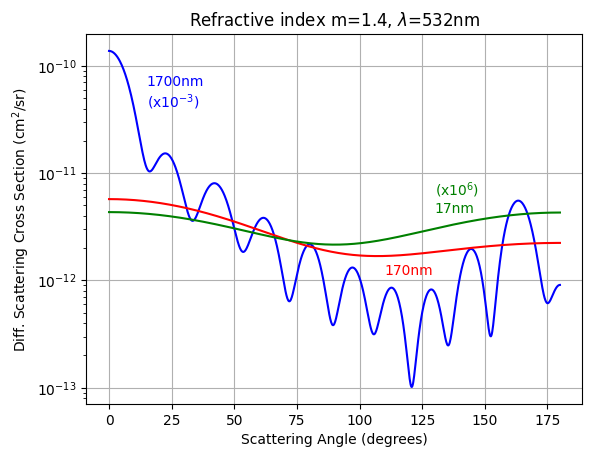

In [5]:
m = 1.4-0j
lambda0 = 532e-9  # m
theta = np.linspace(0,180,1000)
mu = np.cos(theta* np.pi/180)

d = 1700e-9        # m
x = 2 * np.pi/lambda0 * d/2
geometric_cross_section = np.pi * d**2/4 * 1e4  # cm**2
qext, qsca, qback, g = miepython.mie(m,x)
sigma_sca = geometric_cross_section * miepython.i_unpolarized(m,x,mu,'qsca')
plt.semilogy(theta, sigma_sca*1e-3, color='blue')
plt.text(15, sigma_sca[0]*3e-4, "%.0fnm\n(x10$^{-3}$)" % (d*1e9), color='blue')

d = 170e-9         # m
x = 2 * np.pi/lambda0 * d/2
geometric_cross_section = np.pi * d**2/4 * 1e4  # cm**2
qext, qsca, qback, g = miepython.mie(m,x)
sigma_sca = geometric_cross_section * miepython.i_unpolarized(m,x,mu,'qsca')
plt.semilogy(theta, sigma_sca, color='red')
plt.text(110, sigma_sca[-1]/2, "%.0fnm" % (d*1e9), color='red')

d = 17e-9                                                       # m
x = 2 * np.pi/lambda0 * d/2
geometric_cross_section = np.pi * d**2/4 * 1e4                 # cm**2
qext, qsca, qback, g = miepython.mie(m,x)
sigma_sca = geometric_cross_section * miepython.i_unpolarized(m,x,mu,'qsca')
plt.semilogy(theta, sigma_sca*1e6, color='green')
plt.text(130, sigma_sca[-1]*1e6, "(x10$^6$)\n%.0fnm" % (d*1e9), color='green')

plt.title("Refractive index m=1.4, $\lambda$=532nm")
plt.xlabel("Scattering Angle (degrees)")
plt.ylabel("Diff. Scattering Cross Section (cm$^2$/sr)")
plt.grid(True)
plt.show()

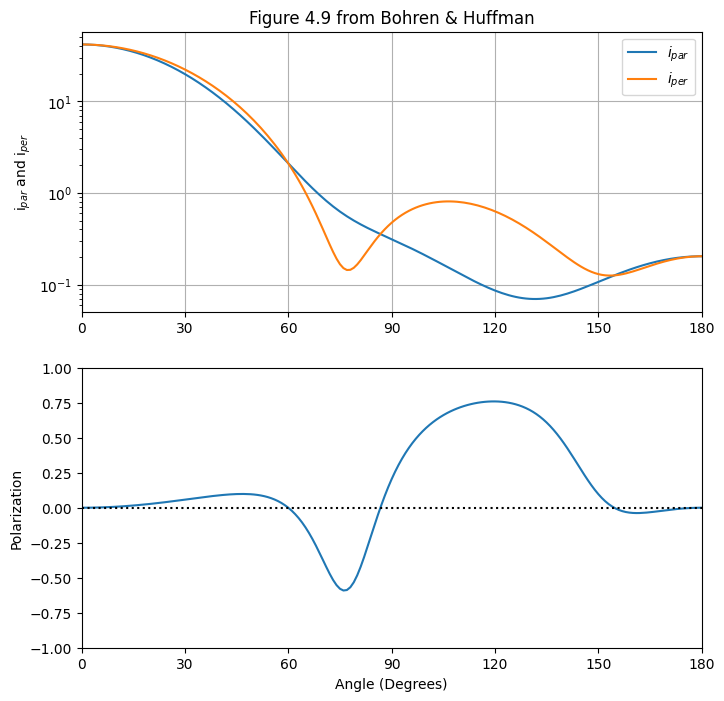

In [6]:
"""Bohren and huffmann"""

x=3
m=1.33-1e-8j

theta = np.linspace(0,180,181)
mu = np.cos(theta*np.pi/180)

scaling_factor = 1/4 #esto es necesario para que coincida con el libro
iper = scaling_factor*miepython.i_per(m,x,mu,'bohren')
ipar = scaling_factor*miepython.i_par(m,x,mu,'bohren')

P = (iper-ipar)/(iper+ipar)

plt.subplots(2,1,figsize=(8,8))
plt.subplot(2,1,1)
plt.semilogy(theta,ipar,label='$i_{par}$')
plt.semilogy(theta,iper,label='$i_{per}$')
plt.xlim(0,180)
plt.xticks(range(0,181,30))
plt.ylabel('i$_{par}$ and i$_{per}$')
plt.legend()
plt.grid(True)
plt.title('Figure 4.9 from Bohren & Huffman')
plt.subplot(2,1,2)
plt.plot(theta,P)
plt.ylim(-1,1)
plt.xticks(range(0,181,30))
plt.xlim(0,180)
plt.ylabel('Polarization')
plt.plot([0,180],[0,0],':k')
plt.xlabel('Angle (Degrees)')
plt.show()
